# UK Road Safety — Cleaning & EDA

**Author:** Leomary Rodriguez
**Project:** Phase 2 Portfolio Project — Mapping and Modeling UK Road Safety

Two files, linked by `Accident_Index`:

- **Accident_Information.csv** — one row per accident
- **Vehicle_Information.csv** — one row per vehicle involved in an accident (an accident with 2 cars has 2 rows here)

I clean the data first, then explore it. The goal is to understand the data well enough to
make good preprocessing and modeling decisions later in the pipeline.

Both files are large (~2 million rows each), so a few cells take a little while to run.

**Getting the data:** the raw CSVs are too big for GitHub, so they are not stored in the repo.
Download them from [Kaggle](https://www.kaggle.com/datasets/tsiaras/uk-road-safety-accidents-and-vehicles/data)
and put both files in `data/raw/`, then run the cells in order. See
[`data/README.md`](../../data/README.md) for more detail.

## Section 0 — Import the libraries we need

Run this first, every time you open the notebook.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 1 — Load the data

In [60]:
accidents = pd.read_csv('../../data/raw/Accident_Information.csv', low_memory=False)
accidents.shape

(2047256, 34)

The vehicle file is not saved as UTF-8, so reading it the normal way gives a
`UnicodeDecodeError`. Adding `encoding='cp1252'` fixes it.

In [61]:
vehicles = pd.read_csv('../../data/raw/Vehicle_Information.csv', low_memory=False, encoding='cp1252')
vehicles.shape

(2177205, 24)

The accident file has 2,047,256 rows and the vehicle file has 2,177,205. The vehicle file is
bigger because it has one row per vehicle, and most accidents involve more than one vehicle.

## Section 2 — First look at the data

Before changing anything, just look: what columns are there, what do the values look like,
what type did pandas guess for each column.

In [62]:
accidents.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [63]:
accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               str    
 1   1st_Road_Class                               str    
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               str    
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            str    
 6   Carriageway_Hazards                          str    
 7   Date                                         str    
 8   Day_of_Week                                  str    
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             str    
 11  Junction_Detail                              str    
 12  Latitude                                     float64
 13  Light_Conditions       

In [64]:
vehicles.head()

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,...,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
0,200401BS00001,26 - 35,3.0,Urban area,4.0,1588.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
1,200401BS00002,26 - 35,NaN,Urban area,3.0,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,109,Data missing or out of range,Front,2004
2,200401BS00003,26 - 35,4.0,Data missing or out of range,NaN,998.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Turning right,1,109,Data missing or out of range,Front,2004
3,200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
4,200401BS00004,26 - 35,1.0,Urban area,4.0,124.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004


In [65]:
vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 2177205 entries, 0 to 2177204
Data columns (total 24 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Accident_Index                    str    
 1   Age_Band_of_Driver                str    
 2   Age_of_Vehicle                    float64
 3   Driver_Home_Area_Type             str    
 4   Driver_IMD_Decile                 float64
 5   Engine_Capacity_.CC.              float64
 6   Hit_Object_in_Carriageway         str    
 7   Hit_Object_off_Carriageway        str    
 8   Journey_Purpose_of_Driver         str    
 9   Junction_Location                 str    
 10  make                              str    
 11  model                             str    
 12  Propulsion_Code                   str    
 13  Sex_of_Driver                     str    
 14  Skidding_and_Overturning          str    
 15  Towing_and_Articulation           str    
 16  Vehicle_Leaving_Carriageway       str    
 17  

In [66]:
print('Accident file years:', accidents['Year'].min(), 'to', accidents['Year'].max())
print('Vehicle file years: ', vehicles['Year'].min(), 'to', vehicles['Year'].max())

Accident file years: 2005 to 2017
Vehicle file years:  2004 to 2016


**The two year ranges do not match.** Accidents cover 2005–2017 but vehicles cover 2004–2016.
So the vehicle file has a year the accident file does not (2004), and the accident file has a
year the vehicle file does not (2017).

This matters because joining the two files later will drop rows. I check exactly how many in
Section 5.

Most columns came in as text rather than numbers. That is normal for this dataset — the
Department for Transport publishes it with readable labels like `'Fine no high winds'`
instead of number codes. It does mean almost every column will need encoding before modeling.

## Section 3 — Find the missing values

`.isnull().sum()` only counts "real" blanks. This dataset also uses text like
`'Data missing or out of range'` or `'NA'` to mean missing, so I need to check those too.

In [67]:
accidents.isnull().sum()

Accident_Index                                       0
1st_Road_Class                                       0
1st_Road_Number                                      2
2nd_Road_Class                                  844272
2nd_Road_Number                                  17593
Accident_Severity                                    0
Carriageway_Hazards                            2007807
Date                                                 0
Day_of_Week                                          0
Did_Police_Officer_Attend_Scene_of_Accident        278
Junction_Control                                     0
Junction_Detail                                      0
Latitude                                           174
Light_Conditions                                     0
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
Location_Easting_OSGR                              164
Location_Northing_OSGR                             164
Longitude 

In [68]:
vehicles.isnull().sum()

Accident_Index                            0
Age_Band_of_Driver                        0
Age_of_Vehicle                       358149
Driver_Home_Area_Type                     0
Driver_IMD_Decile                    734812
Engine_Capacity_.CC.                 265861
Hit_Object_in_Carriageway           2087824
Hit_Object_off_Carriageway          1989741
Journey_Purpose_of_Driver                 0
Junction_Location                         0
make                                 110845
model                                325331
Propulsion_Code                      245843
Sex_of_Driver                             0
Skidding_and_Overturning            1898208
Towing_and_Articulation                   0
Vehicle_Leaving_Carriageway               0
Vehicle_Location.Restricted_Lane       1317
Vehicle_Manoeuvre                         0
Vehicle_Reference                         0
Vehicle_Type                              0
Was_Vehicle_Left_Hand_Drive               0
X1st_Point_of_Impact            

Two columns are almost completely blank: `Carriageway_Hazards` (2,007,807 missing) and
`Special_Conditions_at_Site` (1,995,137 missing). That is about 98% of the rows.

**These are not really missing.** A blank here means there was no hazard and no special
condition, which is normal for a road. They should be filled with `'None'` later, not dropped.

`Driver_IMD_Decile` (734,812 missing) and `Age_of_Vehicle` (358,149 missing) are different —
those are genuinely not recorded.

Now let's check some columns for text-based "missing" values. `.value_counts()` shows every
distinct value in a column and how often it appears — look for anything that means "unknown".

In [69]:
accidents['Junction_Control'].value_counts()

Junction_Control
Give way or uncontrolled               988313
Data missing or out of range           754311
Auto traffic signal                    211335
Not at junction or within 20 metres     77304
Stop sign                               12333
Authorised person                        3660
Name: count, dtype: int64

In [70]:
accidents['Weather_Conditions'].value_counts()

Weather_Conditions
Fine no high winds              1640095
Raining no high winds            239281
Other                             44083
Unknown                           42521
Raining + high winds              28343
Fine + high winds                 25816
Snowing no high winds             13387
Fog or mist                       11068
Snowing + high winds               2487
Data missing or out of range        175
Name: count, dtype: int64

In [71]:
accidents['Road_Type'].value_counts()

Road_Type
Single carriageway              1527882
Dual carriageway                 303407
Roundabout                       136754
One way street                    43258
Slip road                         21558
Unknown                           14396
Data missing or out of range          1
Name: count, dtype: int64

In [72]:
vehicles['Journey_Purpose_of_Driver'].value_counts()

Journey_Purpose_of_Driver
Not known                       834626
Other/Not known (2005-10)       555726
Journey as part of work         391713
Commuting to/from work          202525
Data missing or out of range    133560
Other                            32965
Taking pupil to/from school      21792
Pupil riding to/from school       4298
Name: count, dtype: int64

In [73]:
vehicles['Age_Band_of_Driver'].value_counts()

Age_Band_of_Driver
26 - 35                         450531
36 - 45                         435686
46 - 55                         348762
21 - 25                         238765
56 - 65                         206181
16 - 20                         175874
Data missing or out of range    171052
66 - 75                          91454
Over 75                          54236
11 - 15                           3655
6 - 10                             884
0 - 5                              125
Name: count, dtype: int64

In [74]:
vehicles['Sex_of_Driver'].value_counts()

Sex_of_Driver
Male                            1468081
Female                           633005
Not known                         76051
Data missing or out of range         68
Name: count, dtype: int64

There is a lot of hidden missing data:

- `Junction_Control` — 754,311 rows say `'Data missing or out of range'` (37% of the file)
- `Journey_Purpose_of_Driver` — 834,626 say `'Not known'` plus 133,560 more say
  `'Data missing or out of range'` (45% together)
- `Age_Band_of_Driver` — 171,052 missing
- `Weather_Conditions` — 42,521 say `'Unknown'`
- `Road_Type` — 14,396 say `'Unknown'`
- `Sex_of_Driver` — 76,051 say `'Not known'`

`Junction_Control` and `Journey_Purpose_of_Driver` are missing for over a third of rows, so I
would not build a model on either one without thinking about it carefully first.

One thing I checked before cleaning: `Light_Conditions` has a value called
`'Darkness - lighting unknown'`. That is a **real** observation, not a missing value, and
because it is spelled differently from plain `'Unknown'` my cleaning below will leave it alone.

## Section 4 — Clean the data

Now replace the missing-value text with `np.nan`, so pandas treats it as an actual missing
value. The same four labels show up all over both files, so I replace them across the whole
table at once instead of writing one line per column.

In [75]:
accidents = accidents.replace('Data missing or out of range', np.nan)
accidents = accidents.replace('Unknown', np.nan)
accidents = accidents.replace('Not known', np.nan)
accidents = accidents.replace('NA', np.nan)

In [76]:
vehicles = vehicles.replace('Data missing or out of range', np.nan)
vehicles = vehicles.replace('Unknown', np.nan)
vehicles = vehicles.replace('Not known', np.nan)
vehicles = vehicles.replace('NA', np.nan)

Check that it worked, and that the real `'Darkness - lighting unknown'` value survived.

In [77]:
print('Weather Unknown left over:', (accidents['Weather_Conditions'] == 'Unknown').sum())
print('Junction_Control missing now:', accidents['Junction_Control'].isnull().sum())
print('Darkness - lighting unknown kept:', (accidents['Light_Conditions'] == 'Darkness - lighting unknown').sum())

Weather Unknown left over: 0
Junction_Control missing now: 754311
Darkness - lighting unknown kept: 24362


Good — the placeholders are gone and the genuine `'Darkness - lighting unknown'` category is
still there with 24,362 rows.

The `Date` and `Time` columns are stored as text. Convert `Date` to a real date, and pull out
the hour and month as their own columns — useful later for the time charts.

In [78]:
accidents['Date'] = pd.to_datetime(accidents['Date'], format='%Y-%m-%d')
accidents['Month'] = accidents['Date'].dt.month
accidents['Hour'] = pd.to_datetime(accidents['Time'], format='%H:%M', errors='coerce').dt.hour

In [79]:
print('Date range:', accidents['Date'].min(), 'to', accidents['Date'].max())
print('Rows where Time could not be read:', accidents['Hour'].isnull().sum())

Date range: 2005-01-01 00:00:00 to 2017-12-31 00:00:00
Rows where Time could not be read: 156


All the dates worked. Only 156 rows have a `Time` that could not be read, which is tiny, so I
am ignoring them. `errors='coerce'` turns those bad values into blanks instead of stopping the
whole notebook with an error.

### Values that are wrong but not blank

In [80]:
vehicles['Age_of_Vehicle'].describe()

count    1.819056e+06
mean     7.108167e+00
std      4.725886e+00
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      1.110000e+02
Name: Age_of_Vehicle, dtype: float64

In [81]:
vehicles['Engine_Capacity_.CC.'].describe()

count    1.911344e+06
mean     2.042234e+03
std      1.950143e+03
min      1.000000e+00
25%      1.299000e+03
50%      1.598000e+03
75%      1.997000e+03
max      9.600000e+04
Name: Engine_Capacity_.CC., dtype: float64

In [82]:
vehicles['Vehicle_Type'].value_counts().head(8)

Vehicle_Type
Car                                     1528628
Van / Goods 3.5 tonnes mgw or under      117427
109                                       82920
Bus or coach (17 or more pass seats)      76757
Motorcycle over 500cc                     71472
Motorcycle 125cc and under                61600
Goods 7.5 tonnes mgw and over             55426
Taxi/Private hire car                     43781
Name: count, dtype: int64

Three problems that checking for blanks would never have found:

1. `Age_of_Vehicle` goes up to **111 years** when the middle value is 7. Almost certainly a
   typing error, or a year written in as an age.
2. `Engine_Capacity_.CC.` goes up to **96,000cc** when the middle value is 1,598. No car has a
   96 litre engine.
3. `Vehicle_Type` has readable labels like `'Car'` and `'Pedal cycle'`, but also the plain
   number **`109`** in 82,920 rows. The label was never applied to that code, and no lookup
   table comes with these files.

None of these stop the EDA, but all three need fixing before modeling.

## Section 5 — Quick sanity checks

In [83]:
# how many fully duplicated rows are there?
print('Duplicate rows in accidents:', accidents.duplicated().sum())
print('Duplicate rows in vehicles: ', vehicles.duplicated().sum())

Duplicate rows in accidents: 0
Duplicate rows in vehicles:  0


In [84]:
# Accident_Index should be unique in the accident file (one row per accident) — this should print 0
accidents['Accident_Index'].duplicated().sum()

np.int64(0)

In [85]:
# how many vehicle rows have a matching accident in the accident file?
has_match = vehicles['Accident_Index'].isin(accidents['Accident_Index'])
has_match.value_counts()

Accident_Index
True     2058408
False     118797
Name: count, dtype: int64

In [86]:
# which years are the non-matching vehicle rows from?
vehicles[has_match == False]['Year'].value_counts()

Year
2004    118797
Name: count, dtype: int64

No duplicate rows in either file, and `Accident_Index` is unique across all 2,047,256 accident
rows. So the accident file really is one row per accident.

2,058,408 vehicle rows match an accident and 118,797 do not — that is 94.5% matching. And the
ones that fail are **all from 2004**, which is exactly the year the accident file does not
cover.

That is a good result. It means the join only loses the one year I already knew about, not
random broken rows.

## Section 6 — Save the cleaned data

So next time I don't have to redo Sections 3-4. The later notebooks in the project can read
these files instead of the raw ones.

In [87]:
accidents.to_csv('../../data/processed/accidents_clean.csv', index=False)
vehicles.to_csv('../../data/processed/vehicles_clean.csv', index=False)

---
# EDA

If you're coming back to this later, you can skip straight here after running:
```python
accidents = pd.read_csv('../../data/processed/accidents_clean.csv', low_memory=False)
vehicles = pd.read_csv('../../data/processed/vehicles_clean.csv', low_memory=False)
```

## Section 7 — One column at a time (univariate)

A simple pattern I reuse a lot: `.value_counts()` to count how often each value shows up,
then `.plot(kind='bar')` to draw it.

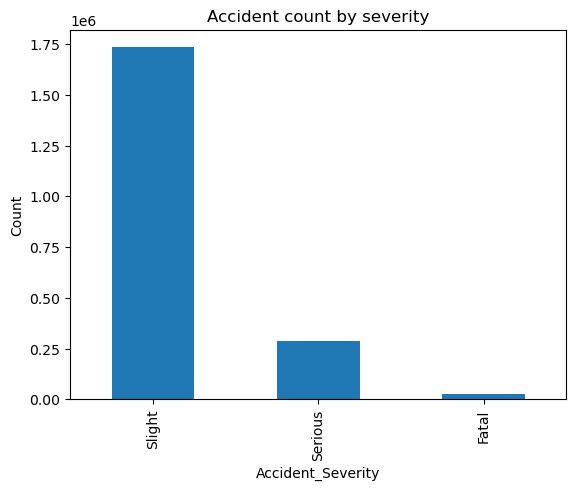

In [88]:
severity_order = ['Slight', 'Serious', 'Fatal']

accidents['Accident_Severity'].value_counts().reindex(severity_order).plot(kind='bar')
plt.title('Accident count by severity')
plt.ylabel('Count')
plt.show()

In [89]:
accidents['Accident_Severity'].value_counts(normalize=True) * 100

Accident_Severity
Slight     84.725506
Serious    13.986478
Fatal       1.288017
Name: proportion, dtype: float64

### This is the most important chart in the notebook

- Slight — 1,734,548 accidents (84.73%)
- Serious — 286,339 accidents (13.99%)
- Fatal — 26,369 accidents (**1.29%**)

Fatal accidents are only 1.29% of the data. That is a big problem for the model we build in
Part 2: a model that just guesses `'Slight'` every single time would be **84.7% accurate** and
completely useless, because it would never once spot a fatal crash.

Three things this means for our team:

- **Accuracy is the wrong score to use.** We need precision, recall and F1, and we need to look
  at the confusion matrix.
- **We have to handle the imbalance**, with class weights or resampling.
- **We could group Fatal and Serious together** into one "Killed or Seriously Injured" class.
  That takes the small class from 1.3% up to 15.3%, which is much easier to model, and it is
  how the Department for Transport reports its own numbers.

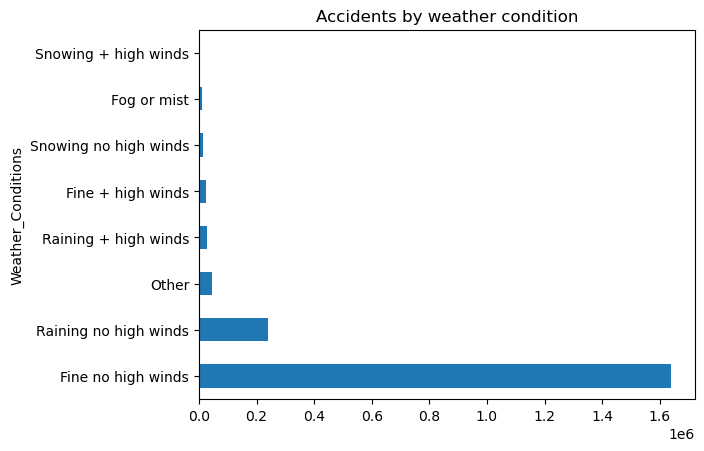

In [90]:
accidents['Weather_Conditions'].value_counts().plot(kind='barh')
plt.title('Accidents by weather condition')
plt.show()

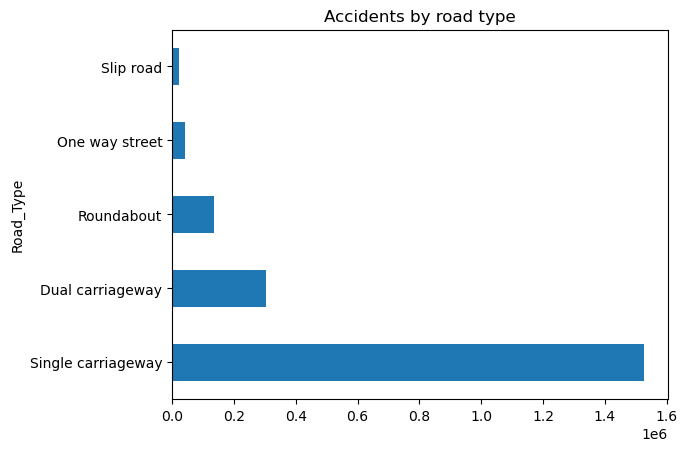

In [91]:
accidents['Road_Type'].value_counts().plot(kind='barh')
plt.title('Accidents by road type')
plt.show()

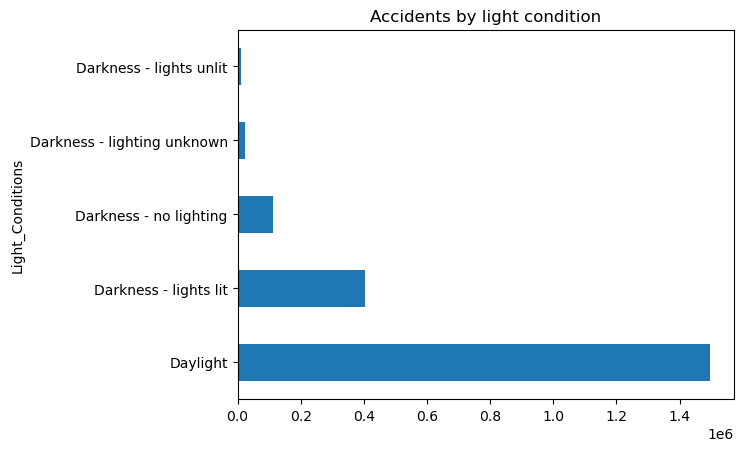

In [92]:
accidents['Light_Conditions'].value_counts().plot(kind='barh')
plt.title('Accidents by light condition')
plt.show()

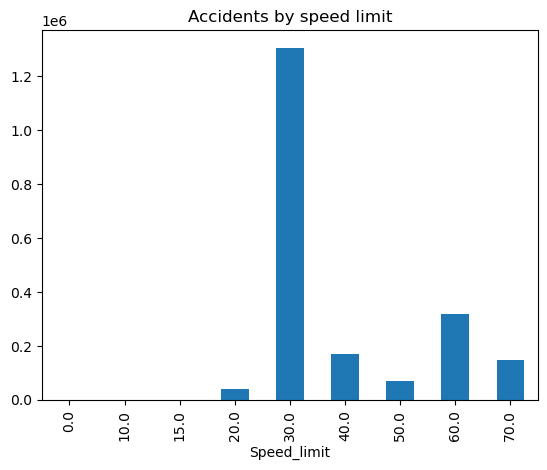

In [93]:
accidents['Speed_limit'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by speed limit')
plt.show()

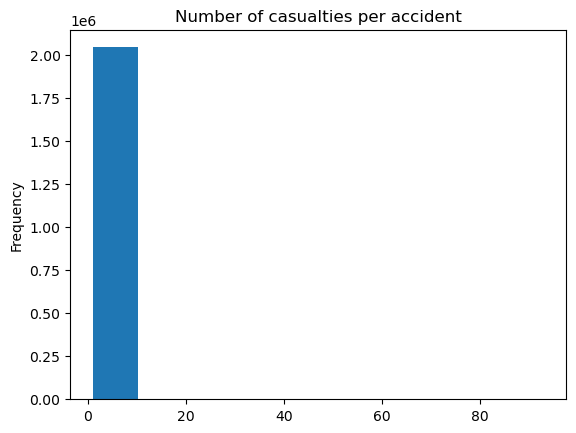

In [94]:
accidents['Number_of_Casualties'].plot(kind='hist', bins=10)
plt.title('Number of casualties per accident')
plt.show()

All four charts say the same thing: **accidents happen where driving happens.**

- 80% in fine weather with no high winds
- 75% on single carriageways
- 73% in daylight
- 64% at a 30 mph speed limit

It would be easy to look at the weather chart and say "fine weather is dangerous", but that is
backwards. These are plain counts, and most UK driving happens in fine weather, in daylight, on
ordinary 30 mph roads — so that is where most crashes happen too.

Counts cannot tell me what is actually risky. For that I need to look at the **percentage** of
each severity inside each category, which is what Section 10 does.

## Section 8 — Trends over time

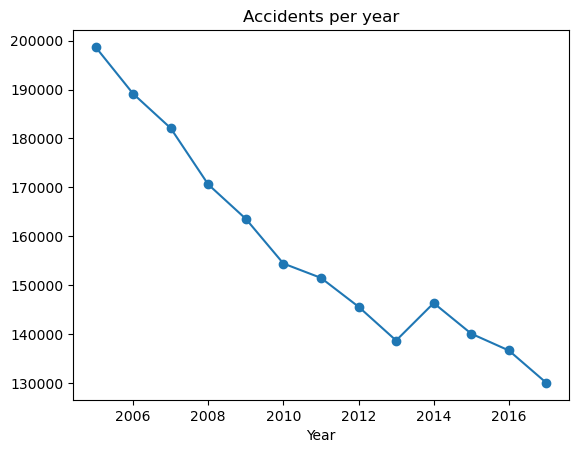

In [95]:
accidents['Year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Accidents per year')
plt.show()

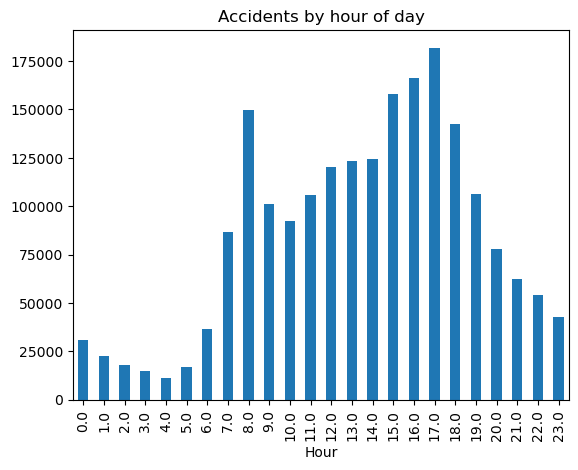

In [96]:
accidents['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by hour of day')
plt.show()

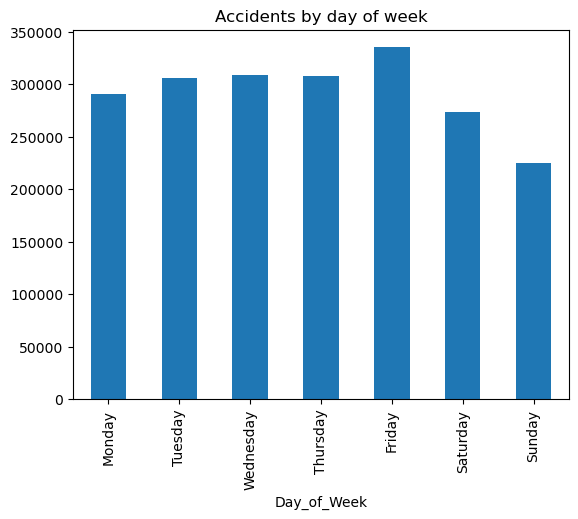

In [97]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents['Day_of_Week'].value_counts().reindex(weekday_order).plot(kind='bar')
plt.title('Accidents by day of week')
plt.show()

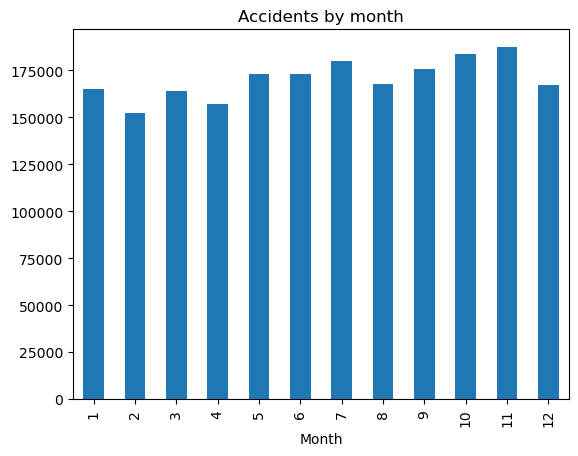

In [98]:
accidents['Month'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by month')
plt.show()

**By year**, accidents drop steadily from 198,735 in 2005 to 129,982 in 2017.

**By hour**, there are two rush hour peaks: a morning one at 08:00 (149,480 accidents) and a
bigger, wider one at 17:00 (181,881). The quietest hour is 04:00 with 11,400. The evening peak
is spread across roughly 15:00–18:00, which makes sense with school runs and people leaving
work at different times.

**By day**, Friday is worst (335,183) and Sunday is best (225,327) — a 49% difference.

**By month**, November is highest (187,483) and February lowest (152,063). The darker autumn
and winter months are all above the summer ones.

One important warning about all of these: they are **counts, not rates**. I don't have traffic
volume data, so I can't tell whether 17:00 is genuinely more dangerous per mile driven or just
busier. Probably both, but this data can't separate them.

## Section 9 — Where accidents happen

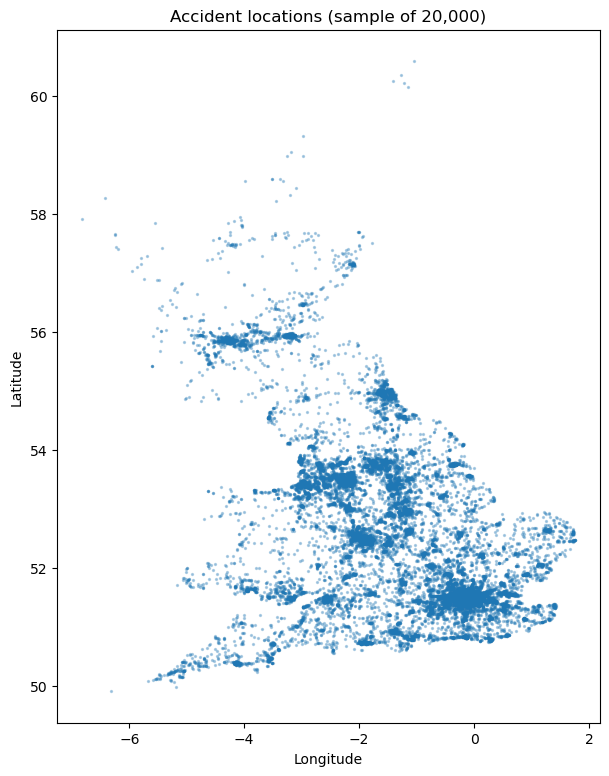

In [99]:
# 2 million points is too many to plot at once, so take a random sample
sample = accidents.sample(20000, random_state=42)

plt.figure(figsize=(7, 9))
plt.scatter(sample['Longitude'], sample['Latitude'], s=2, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accident locations (sample of 20,000)')
plt.show()

With no map underneath, the accidents **draw the shape of Great Britain by themselves**. That
is a nice check that the latitude and longitude columns are correct — only 175 rows are missing
coordinates and all the values sit inside real UK boundaries.

The bright clusters are the big cities (London is obvious in the bottom right) and the lines
between them are the motorways. Northern Scotland is nearly empty because far fewer people
live there.

I used `random_state=42` so the sample is the same every time the notebook runs.

## Section 10 — What relates to severity?

Counting accidents by weather mostly just shows that most driving happens in good weather. To
see if a category is actually *riskier*, look at the **percentage** of each severity within
that category instead.

### Speed limit

In [100]:
speed_severity = accidents.groupby('Speed_limit')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
speed_severity = speed_severity.loc[[20, 30, 40, 50, 60, 70]]
speed_severity * 100

Accident_Severity,Slight,Serious,Fatal
Speed_limit,,,
20.0,84.814709,14.664444,0.520847
30.0,86.564041,12.767824,0.668135
40.0,84.427140,14.103364,1.469496
50.0,82.489673,15.301026,2.209301
60.0,77.544894,19.301097,3.154009
70.0,85.269339,12.410984,2.319677


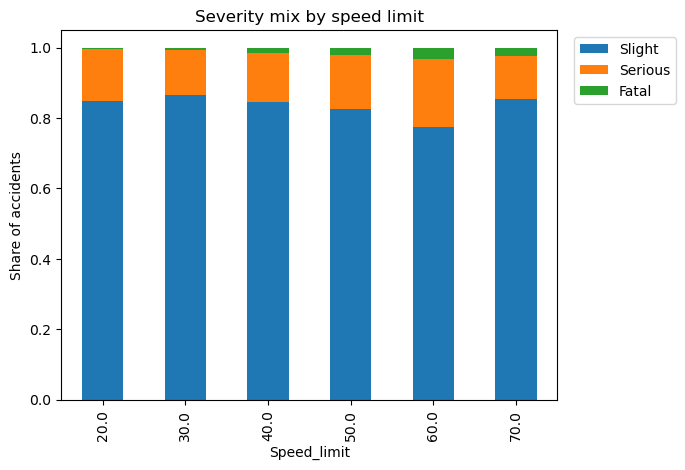

In [101]:
speed_severity.plot(kind='bar', stacked=True)
plt.title('Severity mix by speed limit')
plt.ylabel('Share of accidents')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

The stacked chart is hard to read because fatal accidents are only 1-3%, so the top band is
tiny. Plotting just the fatal percentage on its own makes the pattern clear.

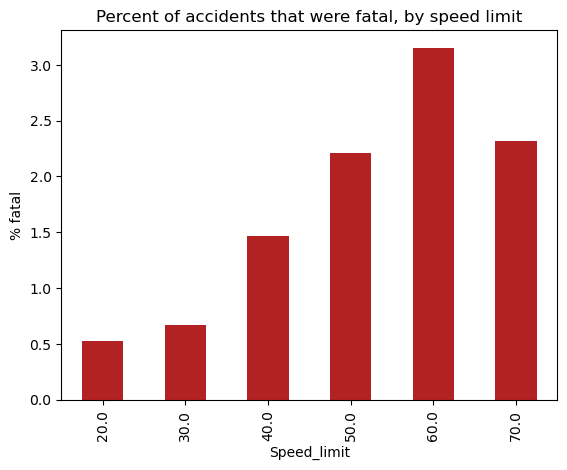

In [102]:
fatal_by_speed = speed_severity['Fatal'] * 100

fatal_by_speed.plot(kind='bar', color='firebrick')
plt.title('Percent of accidents that were fatal, by speed limit')
plt.ylabel('% fatal')
plt.show()

### The 60 mph surprise

The fatal percentage climbs with the speed limit — 0.52% at 20 mph, 0.67% at 30, 1.47% at 40,
2.21% at 50, and **3.15% at 60 mph**. That is what you would expect: faster crashes are harder
to survive.

**Then it goes back down.** At 70 mph it drops to 2.32%, which is safer than 60 mph.

The reason is what kind of road has each limit. 70 mph in Britain means a motorway or a good
dual carriageway — the two directions are separated, there are no pedestrians, and the
junctions are controlled. 60 mph is the default for **country single carriageways**, where two
cars can hit each other head-on at a combined 120 mph, often with no lighting and blind bends.

So the thing that actually matters is **road design, not the number on the sign**. That is a
good reason to include `Road_Type` and `Urban_or_Rural_Area` in the model as well as
`Speed_limit`.

I only plotted the six normal speed limits. There are also 0, 10 and 15 mph limits in the data,
but they have 1, 19 and 16 accidents each, so their percentages jump around and don't mean
anything.

### Light conditions and urban vs rural

In [103]:
light_severity = accidents.groupby('Light_Conditions')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
light_severity * 100

Accident_Severity,Slight,Serious,Fatal
Light_Conditions,,,
Darkness - lighting unknown,85.378869,13.352762,1.268369
Darkness - lights lit,83.436597,15.215369,1.348034
Darkness - lights unlit,82.368870,15.725604,1.905526
Darkness - no lighting,75.730620,19.882106,4.387273
Daylight,85.755898,13.209493,1.034609


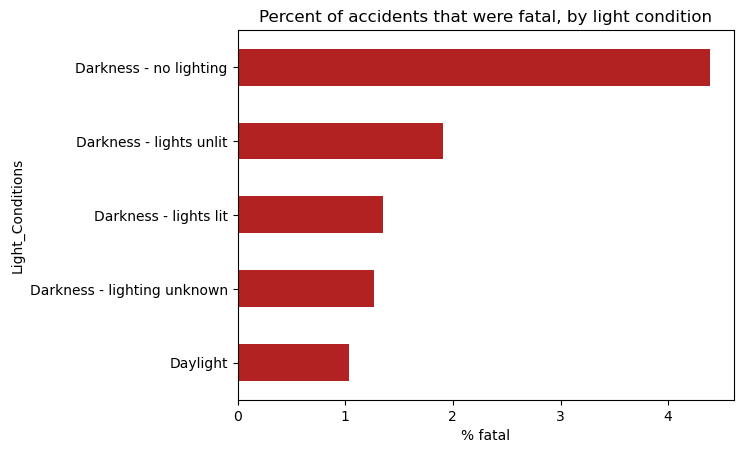

In [104]:
fatal_by_light = light_severity['Fatal'] * 100

fatal_by_light.sort_values().plot(kind='barh', color='firebrick')
plt.title('Percent of accidents that were fatal, by light condition')
plt.xlabel('% fatal')
plt.show()

In [105]:
area_severity = accidents.groupby('Urban_or_Rural_Area')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
area_severity * 100

Accident_Severity,Slight,Serious,Fatal
Urban_or_Rural_Area,,,
Rural,81.148578,16.504566,2.346856
Unallocated,85.000000,15.000000,NaN
Urban,86.685941,12.606223,0.707837


**Street lighting is the strongest single thing I found in the accident file.**

- Daylight — 1.03% fatal
- Darkness, lights lit — 1.35%
- Darkness, lights unlit — 1.91%
- **Darkness, no lighting — 4.39%**

A crash on an unlit road in the dark is **4.3 times more likely to be fatal** than one in
daylight. The clearest comparison is lights lit (1.35%) against no lighting (4.39%) — both are
darkness, and the only difference is whether the road has lights at all.

Urban vs rural shows the same thing: **2.35% fatal in rural areas against 0.71% in urban**,
which is 3.3 times higher.

These findings are all connected. Unlit roads, rural areas and 60 mph single carriageways are
mostly **the same roads**. Together they tell one story: the dangerous places are fast,
undivided, unlit country roads.

### Weather — the opposite of what I expected

In [106]:
weather_severity = accidents.groupby('Weather_Conditions')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
weather_severity * 100

Accident_Severity,Slight,Serious,Fatal
Weather_Conditions,,,
Fine + high winds,82.933065,15.203750,1.863186
Fine no high winds,84.287008,14.382703,1.330289
Fog or mist,83.005060,14.844597,2.150343
Other,87.623347,11.473811,0.902842
Raining + high winds,84.758141,13.830575,1.411283
Raining no high winds,86.378776,12.559710,1.061513
Snowing + high winds,87.535183,11.861681,0.603136
Snowing no high winds,89.108837,10.069470,0.821693


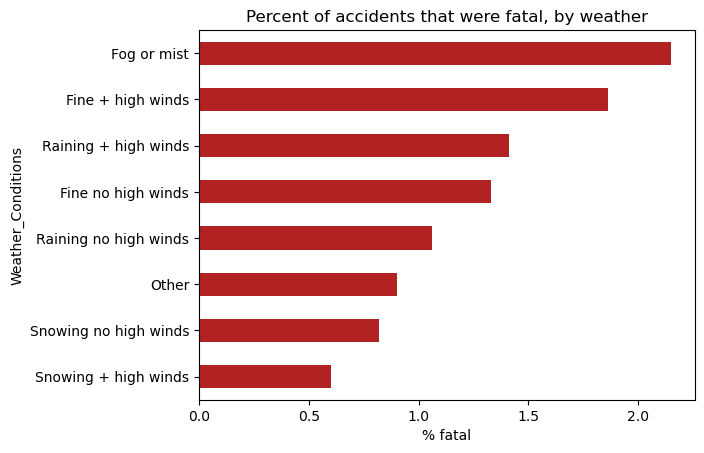

In [107]:
fatal_by_weather = weather_severity['Fatal'] * 100

fatal_by_weather.sort_values().plot(kind='barh', color='firebrick')
plt.title('Percent of accidents that were fatal, by weather')
plt.xlabel('% fatal')
plt.show()

### Accidents in bad weather are *less* likely to be fatal

This was the biggest surprise in the whole notebook:

- Fog or mist — 2.15% fatal
- Fine + high winds — 1.86%
- Raining + high winds — 1.41%
- **Fine, no high winds — 1.33%**
- Raining, no high winds — 1.06%
- **Snowing, no high winds — 0.82%**

Crashes in snow are the *least* likely to be fatal, and rain is also below fine weather.

I don't think this means snow is safe. Two better explanations:

1. **People drive slower when the weather is obviously bad.** Slower crashes are more
   survivable, so bad weather pushes accidents towards Slight even if it causes more of them.
2. **Bad weather stops the kind of driving that kills people** — long fast trips on country
   roads get cancelled first.

**Fog** backs up the first explanation, because it is the deadliest at 2.15%. Fog is the one
condition you can't really feel from inside a warm car until it is too late, so drivers don't
slow down for it the way they do for visible snow.

There is also a catch worth saying out loud: this dataset only has **accidents that happened**.
I have no record of all the journeys where nothing went wrong, so I can't work out a true risk
rate. Everything here is about how bad a crash was *given that a crash happened*, which is a
different question from "how likely am I to crash".

**This must not go on the dashboard without that explanation.** A chart saying "snow is safer
than sunshine" would badly mislead a non-technical reader.

### Road type

In [108]:
road_severity = accidents.groupby('Road_Type')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
road_severity * 100

Accident_Severity,Slight,Serious,Fatal
Road_Type,,,
Dual carriageway,85.880023,12.370842,1.749136
One way street,86.326229,13.003375,0.670396
Roundabout,90.410518,9.281630,0.307852
Single carriageway,83.831539,14.853896,1.314565
Slip road,89.934131,9.295853,0.770016


This fits everything above. **Roundabouts are the safest** at 0.31% fatal, and **dual
carriageways the most dangerous** at 1.75%, with single carriageways just behind at 1.31%.

Roundabouts force everyone to slow down and, more importantly, they get rid of head-on and
right-angle crashes — the two kinds that kill the most people.

### Correlation between the number columns

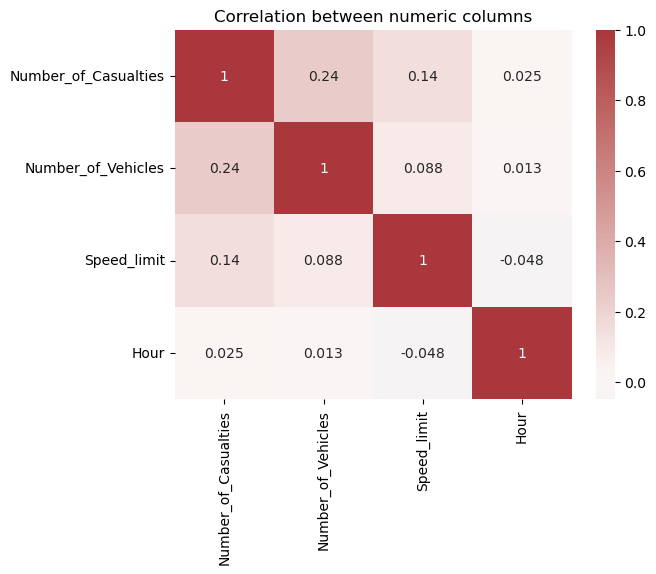

In [109]:
numeric_cols = ['Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit', 'Hour']
corr = accidents[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='vlag', center=0)
plt.title('Correlation between numeric columns')
plt.show()

All of these are weak. The strongest is casualties against number of vehicles (0.237), which
is almost obvious — more cars involved means more people involved. Casualties against speed
limit is 0.143, and hour of day is basically not correlated with anything.

Two things to keep in mind, because a heatmap like this is easy to over-read:

- Correlation only finds **straight-line** relationships. The hour of day pattern is real but
  it has **two peaks**, and a correlation number can't see that shape. The 0.025 means "not a
  straight line", not "no pattern" — Section 8 clearly shows a pattern.
- Only four columns are numbers at all. The strongest things I found — lighting, road type,
  urban vs rural — are all text categories and can't appear on this chart.

So the useful takeaway is that **no single number column predicts severity on its own**. This
is correlation, not cause and effect.

## Section 11 — The vehicle file

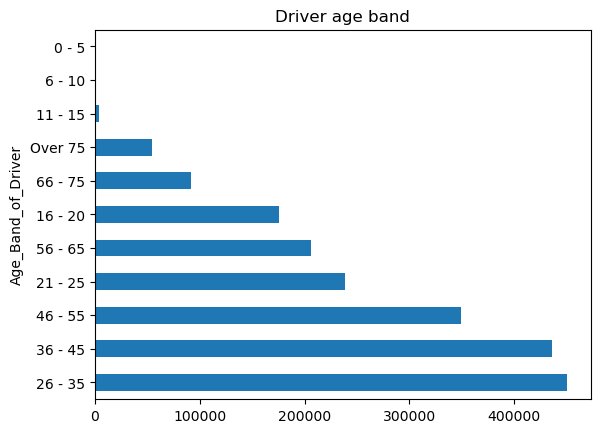

In [110]:
vehicles['Age_Band_of_Driver'].value_counts().plot(kind='barh')
plt.title('Driver age band')
plt.show()

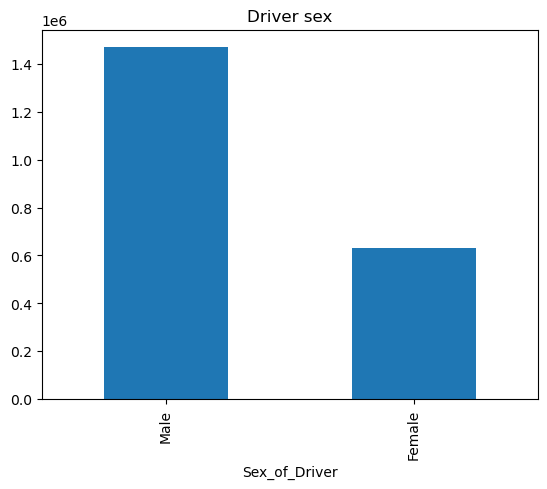

In [111]:
vehicles['Sex_of_Driver'].value_counts().plot(kind='bar')
plt.title('Driver sex')
plt.show()

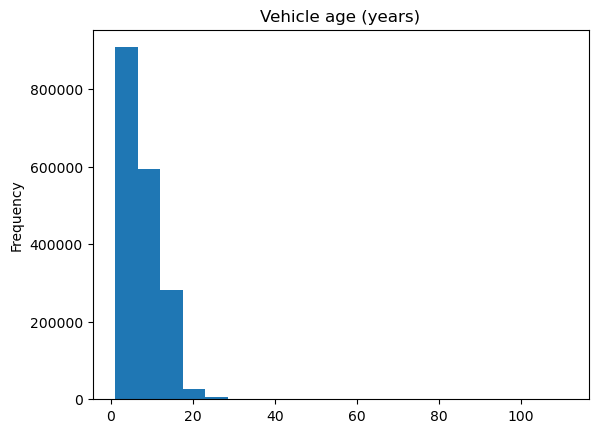

In [112]:
vehicles['Age_of_Vehicle'].plot(kind='hist', bins=20)
plt.title('Vehicle age (years)')
plt.show()

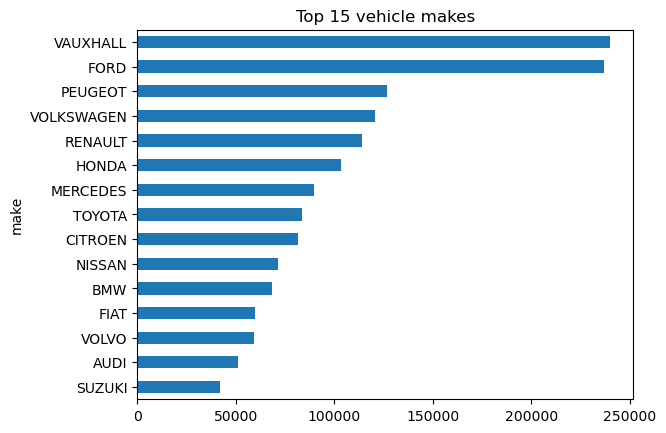

In [113]:
vehicles['make'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 vehicle makes')
plt.gca().invert_yaxis()
plt.show()

**Driver age.** The 26–35 band is biggest (450,531), then 36–45. This mostly follows how many
people of each age drive, so it isn't a risk finding on its own.

The age chart also shows a **data quality problem**: there are 125 drivers in the 0–5 band, 884
in 6–10 and 3,655 in 11–15. Everyone in those bands is below the UK minimum driving age of 17,
so they are almost certainly cyclists — `Age_Band_of_Driver` gets filled in for the "driver" of
any vehicle, including pedal cycles. Worth checking against `Vehicle_Type` before using this
column, and definitely worth not labelling them "child drivers" on a dashboard.

**Driver sex.** 1,468,081 male against 633,005 female, about 70/30. This can't be read as men
being worse drivers without knowing how many miles each group drives, which this data doesn't
tell us.

**Vehicle age.** Most cars are young, median 7 years, with the impossible tail out to 111 years
I found in Section 4.

**Make.** Vauxhall (239,650) and Ford (237,084) are top, which just reflects what people in the
UK were driving. 110,845 rows have no make recorded.

To compare vehicle columns against severity, first attach the severity from the accident file
onto each vehicle row.

In [114]:
vehicles_with_severity = vehicles.merge(accidents[['Accident_Index', 'Accident_Severity']], on='Accident_Index', how='inner')

print('Vehicle rows before the join:', len(vehicles))
print('Vehicle rows after the join: ', len(vehicles_with_severity))

Vehicle rows before the join: 2177205
Vehicle rows after the join:  2058408


In [115]:
manoeuvre_severity = vehicles_with_severity.groupby('Vehicle_Manoeuvre')['Accident_Severity'].value_counts(normalize=True).unstack()[severity_order]
manoeuvre_severity = manoeuvre_severity.sort_values('Fatal')
manoeuvre_severity * 100

Accident_Severity,Slight,Serious,Fatal
Vehicle_Manoeuvre,,,
Waiting to turn left,94.269538,5.541735,0.188728
Waiting to go - held up,94.698538,5.030770,0.270693
Slowing or stopping,93.226181,6.457144,0.316675
Waiting to turn right,91.143976,8.380455,0.475569
Moving off,89.455591,10.036949,0.507460
Turning left,88.640175,10.819309,0.540516
Overtaking static vehicle - offside,82.822779,16.462849,0.714372
Turning right,85.302732,13.975828,0.721440
Reversing,87.665865,11.543486,0.790650


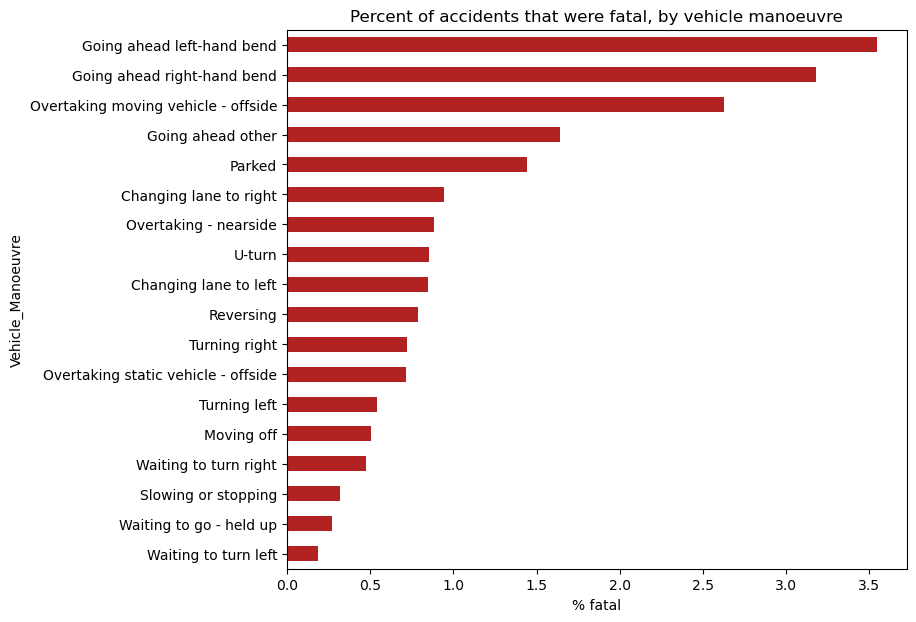

In [116]:
fatal_by_manoeuvre = manoeuvre_severity['Fatal'] * 100

fatal_by_manoeuvre.plot(kind='barh', color='firebrick', figsize=(8, 7))
plt.title('Percent of accidents that were fatal, by vehicle manoeuvre')
plt.xlabel('% fatal')
plt.show()

The join dropped exactly 118,797 rows — the same 2004 rows I predicted in Section 5, which
confirms the merge did what I expected and didn't quietly lose anything else.

The deadliest manoeuvre is **going ahead on a bend** — 3.55% on a left-hand bend and 3.18% on
a right-hand bend — followed by **overtaking a moving vehicle on the offside** at 2.63%.
Bends and overtaking are both things you mostly do on fast country roads, so this is the same
story as Section 10, now visible in what the driver was actually doing.

The safest are all the slow, stop-start manoeuvres: waiting to turn left (0.19%), waiting to go
while held up (0.27%) and slowing or stopping (0.32%).

**One result surprised me.** `Parked` is 1.44% fatal, which is higher than turning, reversing
or changing lane. A parked car isn't doing anything dangerous at all — but if something hits
it, the thing that hit it was probably going fast, and that most likely happened on an unlit
road. So this number is really measuring the *other* vehicle's speed, not the parked car's
behaviour. It is a good reminder that a column describing one vehicle can end up telling you
about a different one.

---
## Section 12 — Summary of findings

**Data quality issues found:**

- 2,047,256 accidents with 34 columns, 2,177,205 vehicles with 24 columns. No duplicate rows in
  either file and `Accident_Index` is unique, so the accident file is clean one-row-per-accident.
- The two files cover different years — accidents 2005–2017, vehicles 2004–2016. The join keeps
  94.5% of vehicle rows and the 118,797 it drops are all from 2004.
- Missing data is often stored as text (`'Data missing or out of range'`, `'Unknown'`,
  `'Not known'`) instead of blanks, so `.isnull()` alone misses it. Worst are
  `Journey_Purpose_of_Driver` (45%) and `Junction_Control` (37%).
- `Carriageway_Hazards` and `Special_Conditions_at_Site` are 98% blank **on purpose** — blank
  means no hazard. They should be filled with `'None'`, not dropped.
- Impossible values that aren't blank: vehicle ages up to 111 years, engines up to 96,000cc,
  and the raw code `109` sitting inside `Vehicle_Type` (82,920 rows).

**Temporal patterns:**

- Accidents fall steadily from 198,735 in 2005 to 129,982 in 2017.
- Two rush hour peaks, 08:00 and a bigger one at 17:00. Quietest at 04:00.
- Friday worst (335,183), Sunday best (225,327).
- November highest, February lowest.

**Geospatial patterns:**

- The coordinates draw the map of Great Britain, clustered on cities and motorways.
- Only 175 rows are missing coordinates and all values are inside real UK boundaries.

**What seems to relate to severity:**

- Severity is very imbalanced: 84.73% Slight, 13.99% Serious, 1.29% Fatal.
- Darkness with no street lighting is the strongest signal — 4.39% fatal vs 1.03% in daylight.
- Rural roads are 3.3x deadlier than urban (2.35% vs 0.71%).
- Fatal percentage rises with speed limit up to 60 mph (3.15%) then **falls** at 70 mph (2.32%),
  because 70 mph means motorways and 60 mph means country roads.
- Roundabouts are the safest road type (0.31%), dual carriageways the worst (1.75%).
- Bad weather accidents are **less** likely to be fatal (snow 0.82% vs fine weather 1.33%),
  most likely because people slow down. Fog is the exception at 2.15%.

**Vehicle/driver patterns:**

- Most drivers are 26–45. Sub-17 age bands are almost certainly cyclists, not drivers.
- 70/30 male to female split, which can't be read as risk without mileage data.
- Vauxhall and Ford are the most common makes.
- Going ahead on a bend is the most fatal manoeuvre (3.55% left-hand, 3.18% right-hand), then
  overtaking on the offside (2.63%). Waiting and slowing are the least (0.19%–0.32%).
  `Parked` is surprisingly high at 1.44%, which probably reflects the speed of whatever hit it.

**Questions to dig into further:**

- Can we get traffic volume data to turn counts into proper rates per mile driven?
- Is there a public STATS19 lookup table that explains `Vehicle_Type` code `109`?
- Are the under-17 driver age bands really pedal cycles?
- Would the casualty-level STATS19 file (not included here) add anything useful?

**What I would tell the rest of the team:**

1. Fill `Carriageway_Hazards` and `Special_Conditions_at_Site` with `'None'` rather than
   dropping them.
2. Cap or remove the impossible `Age_of_Vehicle` and `Engine_Capacity_.CC.` values.
3. Decide what to do with `Vehicle_Type` code `109`.
4. Think hard before using `Journey_Purpose_of_Driver` or `Junction_Control` — both are missing
   more than a third of the time.
5. **Do not score the model on accuracy** — 84.7% is free by always guessing "Slight".
6. Handle the class imbalance with class weights or resampling.
7. Consider combining Fatal + Serious into one KSI target, which takes the small class from
   1.29% to 15.28%.
8. Use `Road_Type` and `Urban_or_Rural_Area` alongside `Speed_limit`, since speed limit alone
   misses the 60/70 mph reversal.
9. On the dashboard, show **percentages not counts**, and explain the weather finding carefully.